In [1]:
from pathlib import Path
import pandas as pd

# notebook is inside /notebooks, so project root is one level up
PROJ = Path("..").resolve()
RAW  = PROJ / "data" / "raw" / "worldbank_labor_econ.xlsx"   # <-- your file
PROC = PROJ / "data" / "processed"
OUT  = PROC / "worldbank_econ_clean.csv"

print("RAW file:", RAW)
assert RAW.exists(), f"Can't find file at: {RAW}"
PROC.mkdir(parents=True, exist_ok=True)

RAW file: /Users/saulerub/Documents/global-labor-compliance-dashboard/data/raw/worldbank_labor_econ.xlsx


In [2]:
df = pd.read_excel(RAW)   # sheet 1 is fine; add sheet_name=0 if you want
df.head()

,Country Name,Country Code,Series Name,Series Code,2000 [YR2000],2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],2005 [YR2005],2006 [YR2006],2007 [YR2007],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023]
0,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,174.930991,138.706822,178.954088,198.871116,221.763654,254.184249,274.218554,376.223152,522.082216,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895
1,Afghanistan,AFG,"Labor force participation rate, total (% of to...",SL.TLF.CACT.ZS,46.571,46.533,46.508,46.499,46.507,46.532,46.57,46.621,47.235,47.305,45.57,43.823,41.579,40.932,37.64,37.673
2,Afghanistan,AFG,Employment in agriculture (% of total employme...,SL.AGR.EMPL.ZS,65.651597,65.025449,64.186689,63.481557,62.469948,61.703552,60.893812,60.190752,44.36949,43.989028,44.248271,45.050959,45.983411,45.955199,45.592654,45.463952
3,Afghanistan,AFG,Employment in industry (% of total employment)...,SL.IND.EMPL.ZS,9.685095,9.833793,10.013898,10.340424,10.808873,11.227758,11.63467,11.860039,19.295988,18.026459,18.30766,18.214766,18.481312,18.522262,18.540741,18.386784
4,Afghanistan,AFG,Employment in services (% of total employment)...,SL.SRV.EMPL.ZS,24.663309,25.140758,25.799413,26.178019,26.721179,27.06869,27.471518,27.949191,36.334523,37.984513,37.444069,36.734276,35.535277,35.522526,35.866618,36.149276


In [3]:
id_cols = ["Country Name", "Country Code", "Series Name", "Series Code"]
year_cols = [c for c in df.columns if (isinstance(c, int) or str(c).isdigit())]

long = (
    df[id_cols + year_cols]
    .melt(id_vars=id_cols, var_name="year", value_name="value")
    .dropna(subset=["value"])
)
long["year"] = long["year"].astype(int)
long.head()

,Country Name,Country Code,Series Name,Series Code,year,value


In [4]:
indicator_map = {
    "NY.GDP.MKTP.CD":  "gdp_current_usd",
    "SL.TLF.CACT.ZS":  "lfpr_total_pct",
    "SL.AGR.EMPL.ZS":  "emp_agriculture_pct",
    "SL.IND.EMPL.ZS":  "emp_industry_pct",
    "SL.SRV.EMPL.ZS":  "emp_services_pct",
    "SL.UEM.TOTL.ZS":  "unemp_total_pct",
    "SE.TER.ENRR":     "school_enroll_tertiary_pct",
    "SL.GDP.PCAP.EM.KD": "gdp_per_worker_ppp_const"
}

keep = long[long["Series Code"].isin(indicator_map.keys())].copy()
keep["indicator"] = keep["Series Code"].map(indicator_map)
keep.head()

,Country Name,Country Code,Series Name,Series Code,year,value,indicator


In [5]:
tidy = (
    keep
    .pivot_table(
        index=["Country Code", "Country Name", "year"],
        columns="indicator",
        values="value",
        aggfunc="first"
    )
    .reset_index()
)

tidy = tidy.rename(columns={"Country Code": "iso3", "Country Name": "country"})
tidy = tidy.sort_values(["iso3", "year"]).reset_index(drop=True)

tidy.head()

indicator,iso3,country,year


In [6]:
tidy.to_csv(OUT, index=False)
print("Saved cleaned file to:", OUT)

Saved cleaned file to: /Users/saulerub/Documents/global-labor-compliance-dashboard/data/processed/worldbank_econ_clean.csv


In [7]:
import pandas as pd
from pathlib import Path

# paths
PROJ = Path("..").resolve()
PROC = PROJ / "data" / "processed"
OUT  = PROC / "worldbank_econ_clean.csv"

wb = pd.read_csv(OUT)
print("✅ Loaded:", OUT)
print("Shape:", wb.shape)
display(wb.head(3))

✅ Loaded: /Users/saulerub/Documents/global-labor-compliance-dashboard/data/processed/worldbank_econ_clean.csv
Shape: (0, 3)


,iso3,country,year


In [8]:
print("\n--- .info() ---")
wb.info()

print("\n--- Coverage ---")
print("Countries:", wb['iso3'].nunique())
print("Years:", wb['year'].min(), "→", wb['year'].max())

print("\nTop 5 country-year counts:")
display(wb.groupby('iso3')['year'].nunique().sort_values(ascending=False).head())

print("\nAny duplicates on (iso3, year)?")
dups = wb.duplicated(['iso3','year']).sum()
print("Duplicates:", dups)
assert dups == 0, "There are duplicate iso3-year rows."


--- .info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   iso3     0 non-null      object
 1   country  0 non-null      object
 2   year     0 non-null      object
dtypes: object(3)
memory usage: 132.0+ bytes

--- Coverage ---
Countries: 0
Years: nan → nan

Top 5 country-year counts:


Series([], Name: year, dtype: int64)


Any duplicates on (iso3, year)?
Duplicates: 0


In [9]:
print("\n--- Missing values ---")
na = wb.isna().sum().sort_values(ascending=False).to_frame('n_missing')
na['pct'] = (na['n_missing'] / len(wb) * 100).round(2)
display(na)

# peek at a few rows with any missing
sample_missing = wb[wb.isna().any(axis=1)].head(10)
print("\nSample rows with any missing:")
display(sample_missing)


--- Missing values ---


,n_missing,pct
iso3,0,NaN
country,0,NaN
year,0,NaN



Sample rows with any missing:


,iso3,country,year


In [10]:
import numpy as np

checks = []

def add_flag(df, cond, flag):
    f = df.loc[cond, ['iso3','country','year']].copy()
    f['flag'] = flag
    return f

# percentages that should be within [0, 100] (allow tiny floating tolerance)
pct_cols_0_100 = [
    'lfpr_total_pct',
    'emp_agriculture_pct', 'emp_industry_pct', 'emp_services_pct',
    'unemp_total_pct'
]
for c in pct_cols_0_100:
    if c in wb.columns:
        checks.append(add_flag(wb, (wb[c] < -0.1) | (wb[c] > 100.1), f"{c} out of [0,100]"))

# school tertiary gross enrollment can exceed 100 in some cases ( >100 is possible ), 
# but negative is not OK
if 'school_enroll_tertiary_pct' in wb.columns:
    checks.append(add_flag(wb, wb['school_enroll_tertiary_pct'] < -0.1,
                           "school_enroll_tertiary_pct negative"))

# GDP (current USD) should be non-negative; 0 can appear for small/islands but negative is not OK
if 'gdp_current_usd' in wb.columns:
    checks.append(add_flag(wb, wb['gdp_current_usd'] < -1, "gdp_current_usd negative"))

# GDP per worker (constant PPP) should be positive if present
if 'gdp_per_worker_ppp_const' in wb.columns:
    checks.append(add_flag(wb, wb['gdp_per_worker_ppp_const'] <= 0,
                           "gdp_per_worker_ppp_const <= 0"))

issues = pd.concat(checks, ignore_index=True) if checks else pd.DataFrame()
print("\n--- Range issues ---")
print("Rows flagged:", len(issues))
display(issues.head(10))


--- Range issues ---
Rows flagged: 0


""


In [11]:
if set(['emp_agriculture_pct','emp_industry_pct','emp_services_pct']).issubset(wb.columns):
    tmp = wb[['iso3','country','year',
              'emp_agriculture_pct','emp_industry_pct','emp_services_pct']].dropna()
    tmp['sector_sum'] = (tmp['emp_agriculture_pct'] +
                         tmp['emp_industry_pct'] +
                         tmp['emp_services_pct'])
    tmp['abs_diff_from_100'] = (tmp['sector_sum'] - 100).abs()
    off = tmp[tmp['abs_diff_from_100'] > 5]  # tolerance: 5 pp
    print("\n--- Sector-sum ≈ 100 check ---")
    print("Rows off by >5pp:", len(off))
    display(off.head(10))
else:
    print("\nSector share columns not all present; skipping sector-sum check.")


Sector share columns not all present; skipping sector-sum check.


In [14]:
# 1) Read Excel (already done just above)
df = pd.read_excel(RAW)

# 2) Identify year columns and melt to long
year_cols = [c for c in df.columns if str(c).startswith("19") or str(c).startswith("20")]
id_cols   = ["Country Name", "Country Code", "Series Code"]
long = df.melt(id_vars=id_cols, value_vars=year_cols,
               var_name="year", value_name="value")

# 3) Clean the 'year' and 'value' columns
#    - convert "2000 [YR2000]" -> 2000
#    - coerce numeric values (turn ".." etc. into NaN)
import re
long["year"]  = long["year"].astype(str).str.extract(r"(\d{4})").astype("Int64")
long["value"] = pd.to_numeric(long["value"], errors="coerce")

# 4) Keep only the indicators you selected
long = long[long["Series Code"].isin(indicator_map.keys())]

# 5) If there are duplicate (country, series, year) rows, collapse them safely
long = (long
        .groupby(["Country Code", "Country Name", "Series Code", "year"], as_index=False)
        .agg({"value":"mean"}))

# 6) Pivot to wide: one column per indicator
wide = (long
        .pivot_table(index=["Country Code","Country Name","year"],
                     columns="Series Code", values="value",
                     aggfunc="first")      # no averaging needed after step 5
        .reset_index())

# 7) Friendly column names and types
wide = wide.rename(columns=indicator_map)
wide = wide.rename(columns={"Country Code": "iso3", "Country Name": "country"})
wide["year"] = wide["year"].astype("Int64")

# 8) Save
wide.to_csv(OUT, index=False)
print(f"✅ Cleaned file saved to {OUT}")
display(wide.head())

✅ Cleaned file saved to /Users/saulerub/Documents/global-labor-compliance-dashboard/data/processed/worldbank_econ_clean.csv


Series Code,iso3,country,year,school_enroll_tertiary_pct,emp_agriculture_pct,gdp_per_worker_ppp_const,emp_industry_pct,emp_services_pct,lfpr_total_pct,unemp_total_pct
0,ABW,Aruba,2000,27.973761,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,Aruba,2001,29.228010,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,Aruba,2002,28.924419,NaN,NaN,NaN,NaN,NaN,NaN
3,ABW,Aruba,2003,29.782690,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,Aruba,2004,29.293449,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# 1) Re‑load the freshly written file
from pathlib import Path
import pandas as pd

OUT = Path("../data/processed/worldbank_econ_clean.csv")
wb = pd.read_csv(OUT)

# 2) Clean small quirks
# Drop any accidental column named exactly "Series Code" (can appear after pivot)
wb = wb.drop(columns=[c for c in wb.columns if c.strip().lower() == "series code"], errors="ignore")

# Ensure types
wb["year"] = wb["year"].astype("Int64")

num_cols = [c for c in wb.columns
            if c.endswith("_pct") or c in ["gdp_current_usd", "gdp_per_worker_ppp_const"]]
wb[num_cols] = wb[num_cols].apply(pd.to_numeric, errors="coerce")

print(len(wb), "rows,", len(num_cols), "numeric cols found")
wb.head()

3863 rows, 7 numeric cols found


,iso3,country,year,school_enroll_tertiary_pct,emp_agriculture_pct,gdp_per_worker_ppp_const,emp_industry_pct,emp_services_pct,lfpr_total_pct,unemp_total_pct
0,ABW,Aruba,2000,27.973761,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,Aruba,2001,29.228010,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,Aruba,2002,28.924419,NaN,NaN,NaN,NaN,NaN,NaN
3,ABW,Aruba,2003,29.782690,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,Aruba,2004,29.293449,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
# 3) Quick stats snapshot
desc = wb[num_cols].describe(percentiles=[.05, .5, .95]).T.round(2)
desc

,count,mean,std,min,5%,50%,95%,max
school_enroll_tertiary_pct,2735.0,37.16,27.50,0.21,3.42,31.56,84.46,166.67
emp_agriculture_pct,3756.0,27.62,22.34,0.09,1.39,22.64,68.29,91.93
gdp_per_worker_ppp_const,3585.0,48530.70,45589.74,1568.69,4821.51,35411.02,133593.41,318423.17
emp_industry_pct,3756.0,19.85,7.62,2.25,7.13,20.29,32.19,54.55
emp_services_pct,3756.0,52.54,18.13,5.82,22.30,52.86,79.23,93.44
lfpr_total_pct,3756.0,61.08,10.25,23.09,43.24,61.43,78.53,88.35
unemp_total_pct,3756.0,7.73,5.48,0.10,1.78,6.15,19.08,37.32


In [18]:
# 4) Simple range/logic checks (optional but helpful)
bad_pct = {}
for c in [c for c in num_cols if c.endswith("_pct")]:
    out_of_range = wb[(wb[c] < -0.1) | (wb[c] > 100.1)][["iso3","country","year",c]]
    if not out_of_range.empty:
        bad_pct[c] = len(out_of_range)

print("Pct columns with out-of-range rows:", bad_pct or "none")

# Sector shares ≈ 100 (only if all three present for the row)
req = ["emp_agriculture_pct","emp_industry_pct","emp_services_pct"]
if set(req).issubset(wb.columns):
    tmp = wb.dropna(subset=req, how="any").copy()
    tmp["sum"] = tmp[req].sum(axis=1)
    off = tmp[ tmp["sum"].sub(100).abs() > 5 ]  # 5 percentage‑point tolerance
    print("Rows where sector shares deviate >5pp:", len(off))
else:
    print("Sector share check skipped (not all three columns present).")

Pct columns with out-of-range rows: {'school_enroll_tertiary_pct': 33}
Rows where sector shares deviate >5pp: 0


In [20]:
indicator_map = {
    "NY.GDP.PCAP.CD": "gdp_per_capita_usd",       # NEW: GDP per capita (current US$)
    "SL.TLF.CACT.ZS": "lfpr_total_pct",
    "SL.AGR.EMPL.ZS": "emp_agriculture_pct",
    "SL.IND.EMPL.ZS": "emp_industry_pct",
    "SL.SRV.EMPL.ZS": "emp_services_pct",
    "SL.UEM.TOTL.ZS": "unemp_total_pct",
    "SE.TER.ENRR":    "school_enroll_tertiary_pct",
    "SL.GDP.PCAP.EM.KD": "gdp_per_worker_ppp_const"
    # (OPTIONAL) If you also want total GDP (current US$), include:
    # "NY.GDP.MKTP.CD": "gdp_total_current_usd",
}

In [22]:
df = pd.read_excel(RAW)  # same RAW path you used
print(any(df["Series Code"].eq("NY.GDP.PCAP.CD")))
df[df["Series Code"].eq("NY.GDP.PCAP.CD")]["Series Name"].head()

True


0     GDP per capita (current US$)
8     GDP per capita (current US$)
16    GDP per capita (current US$)
24    GDP per capita (current US$)
32    GDP per capita (current US$)
Name: Series Name, dtype: object

In [23]:
indicator_map = {
    "NY.GDP.PCAP.CD": "gdp_per_capita_usd",   # <-- this must be here
    "SL.TLF.CACT.ZS": "lfpr_total_pct",
    "SL.AGR.EMPL.ZS": "emp_agriculture_pct",
    "SL.IND.EMPL.ZS": "emp_industry_pct",
    "SL.SRV.EMPL.ZS": "emp_services_pct",
    "SL.UEM.TOTL.ZS": "unemp_total_pct",
    "SE.TER.ENRR": "school_enroll_tertiary_pct",
    "SL.GDP.PCAP.EM.KD": "gdp_per_worker_ppp_const",
}

In [24]:
df = pd.read_excel(RAW)

In [25]:
id_cols = ["Country Name", "Country Code", "Series Name", "Series Code"]
year_cols = [c for c in df.columns if c.startswith("19") or c.startswith("20")]

long = df.melt(id_vars=id_cols, value_vars=year_cols,
               var_name="year", value_name="value")
long["year"] = long["year"].str.extract("(\d+)").astype(int)
long["value"] = pd.to_numeric(long["value"], errors="coerce")

<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
/var/folders/k_/ds6qyxyd6lzbpp2lp968mbsr0000gn/T/ipykernel_39913/1991899606.py:6: SyntaxWarning: invalid escape sequence '\d'
  long["year"] = long["year"].str.extract("(\d+)").astype(int)


In [26]:
long = long[long["Series Code"].isin(indicator_map.keys())]

In [27]:
wide = (long
        .groupby(["Country Code","Country Name","Series Code","year"], as_index=False)
        .agg({"value":"mean"})      # collapse duplicates if any
        .pivot_table(index=["Country Code","Country Name","year"],
                     columns="Series Code", values="value")
        .reset_index())

In [28]:
wide = wide.rename(columns=indicator_map)
wide = wide.rename(columns={"Country Code":"iso3", "Country Name":"country"})

In [29]:
wide.to_csv(OUT, index=False)
print("✅ Cleaned file saved to", OUT)

✅ Cleaned file saved to ../data/processed/worldbank_econ_clean.csv


In [30]:
wb = pd.read_csv(OUT)
print(wb.columns.tolist())

['iso3', 'country', 'year', 'gdp_per_capita_usd', 'school_enroll_tertiary_pct', 'emp_agriculture_pct', 'gdp_per_worker_ppp_const', 'emp_industry_pct', 'emp_services_pct', 'lfpr_total_pct', 'unemp_total_pct']


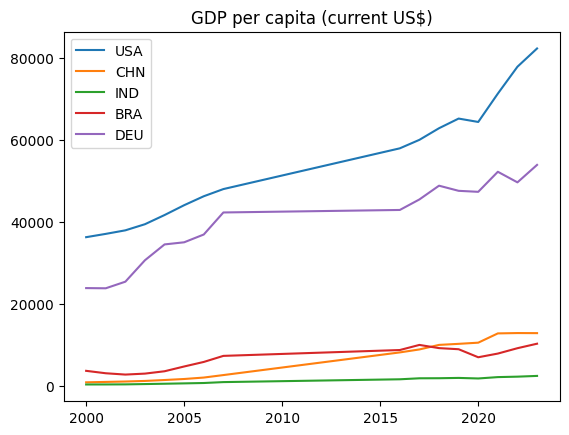

In [31]:
import matplotlib.pyplot as plt

countries = ["USA", "CHN", "IND", "BRA", "DEU"]
for c in countries:
    sub = wb[wb["iso3"] == c].sort_values("year")
    plt.plot(sub["year"], sub["gdp_per_capita_usd"], label=c)

plt.title("GDP per capita (current US$)")
plt.legend(); plt.show()

In [32]:
import matplotlib.pyplot as plt

sample_countries = ["USA", "CHN", "IND", "BRA", "DEU"]  # tweak as you like

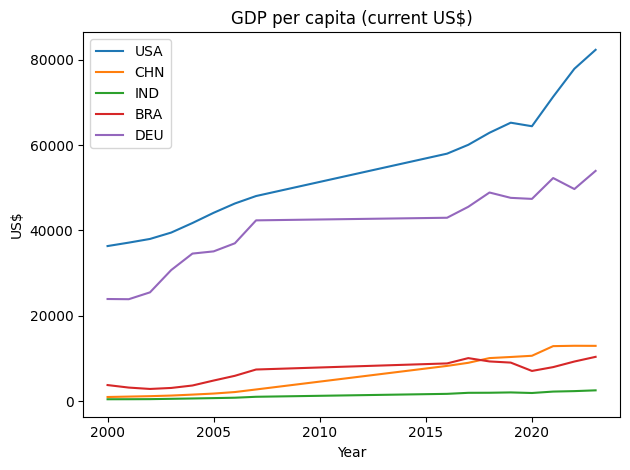

In [33]:
plt.figure()
for c in sample_countries:
    sub = wb[wb["iso3"] == c].sort_values("year")
    plt.plot(sub["year"], sub["gdp_per_capita_usd"], label=c)
plt.title("GDP per capita (current US$)")
plt.xlabel("Year"); plt.ylabel("US$"); plt.legend(); plt.tight_layout()

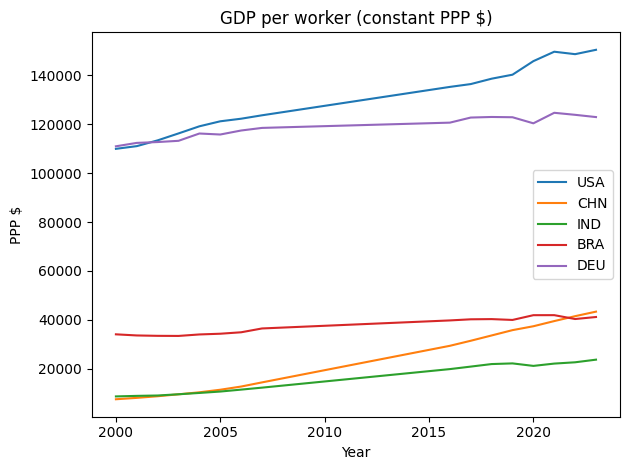

In [34]:
plt.figure()
for c in sample_countries:
    sub = wb[wb["iso3"] == c].sort_values("year")
    plt.plot(sub["year"], sub["gdp_per_worker_ppp_const"], label=c)
plt.title("GDP per worker (constant PPP $)")
plt.xlabel("Year"); plt.ylabel("PPP $"); plt.legend(); plt.tight_layout()

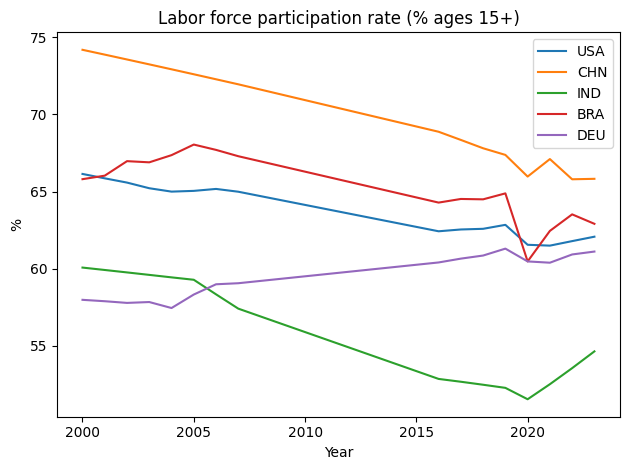

In [35]:
plt.figure()
for c in sample_countries:
    sub = wb[wb["iso3"] == c].sort_values("year")
    plt.plot(sub["year"], sub["lfpr_total_pct"], label=c)
plt.title("Labor force participation rate (% ages 15+)")
plt.xlabel("Year"); plt.ylabel("%"); plt.legend(); plt.tight_layout()

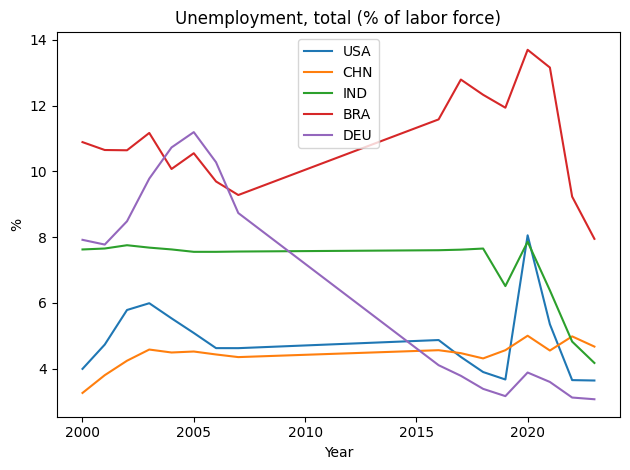

In [36]:
plt.figure()
for c in sample_countries:
    sub = wb[wb["iso3"] == c].sort_values("year")
    plt.plot(sub["year"], sub["unemp_total_pct"], label=c)
plt.title("Unemployment, total (% of labor force)")
plt.xlabel("Year"); plt.ylabel("%"); plt.legend(); plt.tight_layout()

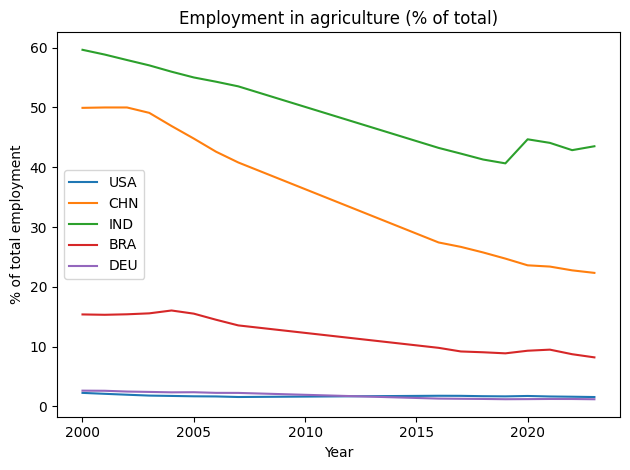

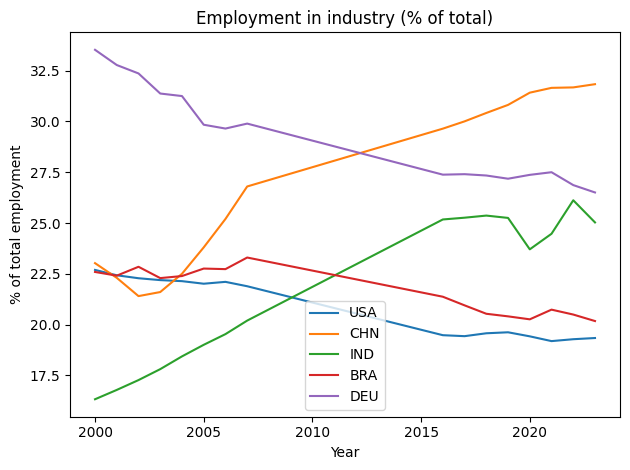

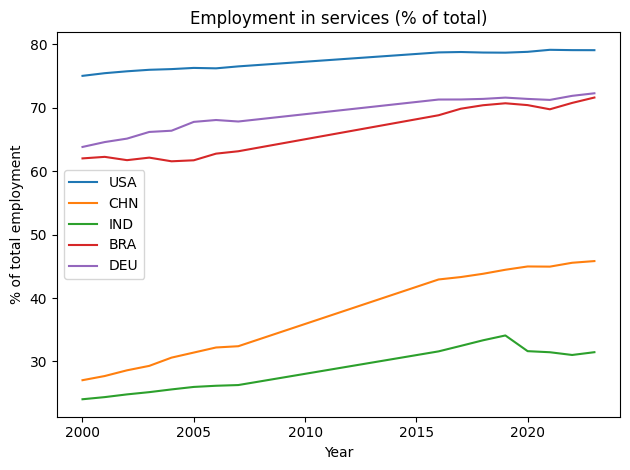

In [37]:
for col, title in [
    ("emp_agriculture_pct", "Employment in agriculture (% of total)"),
    ("emp_industry_pct",    "Employment in industry (% of total)"),
    ("emp_services_pct",    "Employment in services (% of total)"),
]:
    plt.figure()
    for c in sample_countries:
        sub = wb[wb["iso3"] == c].sort_values("year")
        plt.plot(sub["year"], sub[col], label=c)
    plt.title(title)
    plt.xlabel("Year"); plt.ylabel("% of total employment"); plt.legend(); plt.tight_layout()

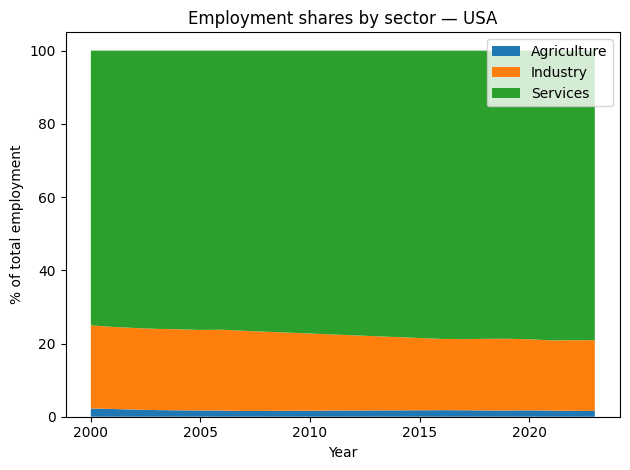

In [38]:
country = "USA"  # change to CHN, IND, etc.
sub = wb[wb["iso3"] == country].sort_values("year")[["year","emp_agriculture_pct","emp_industry_pct","emp_services_pct"]].dropna()

plt.figure()
plt.stackplot(
    sub["year"],
    sub["emp_agriculture_pct"],
    sub["emp_industry_pct"],
    sub["emp_services_pct"],
    labels=["Agriculture","Industry","Services"]
)
plt.title(f"Employment shares by sector — {country}")
plt.xlabel("Year"); plt.ylabel("% of total employment"); plt.legend(loc="upper right"); plt.tight_layout()

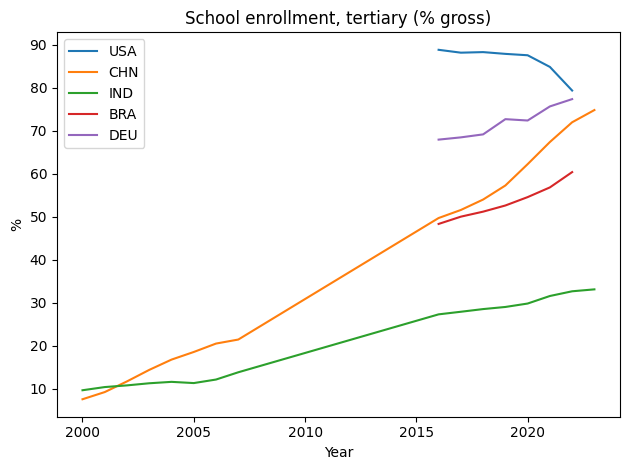

In [39]:
plt.figure()
for c in sample_countries:
    sub = wb[wb["iso3"] == c].sort_values("year")
    plt.plot(sub["year"], sub["school_enroll_tertiary_pct"], label=c)
plt.title("School enrollment, tertiary (% gross)")
plt.xlabel("Year"); plt.ylabel("%"); plt.legend(); plt.tight_layout()

In [40]:
import numpy as np
have_cols = ["gdp_per_capita_usd","gdp_per_worker_ppp_const","lfpr_total_pct","unemp_total_pct",
             "emp_agriculture_pct","emp_industry_pct","emp_services_pct","school_enroll_tertiary_pct"]

cov = (wb[["iso3"]+have_cols]
       .groupby("iso3")
       .apply(lambda g: g[have_cols].notna().any())
       .astype(int)
       .sort_index())

# simple text heatmap
print("Coverage (1=has any data):")
display(cov.head(20))

Coverage (1=has any data):


/var/folders/k_/ds6qyxyd6lzbpp2lp968mbsr0000gn/T/ipykernel_39913/883087483.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g[have_cols].notna().any())


,gdp_per_capita_usd,gdp_per_worker_ppp_const,lfpr_total_pct,unemp_total_pct,emp_agriculture_pct,emp_industry_pct,emp_services_pct,school_enroll_tertiary_pct
iso3,,,,,,,,
ABW,1,0,0,0,0,0,0,1
AFE,1,1,1,1,1,1,1,1
AFG,1,1,1,1,1,1,1,1
AFW,1,1,1,1,1,1,1,1
AGO,1,1,1,1,1,1,1,1
ALB,1,1,1,1,1,1,1,1
AND,1,0,0,0,0,0,0,1
ARB,1,1,1,1,1,1,1,1
ARE,1,1,1,1,1,1,1,1


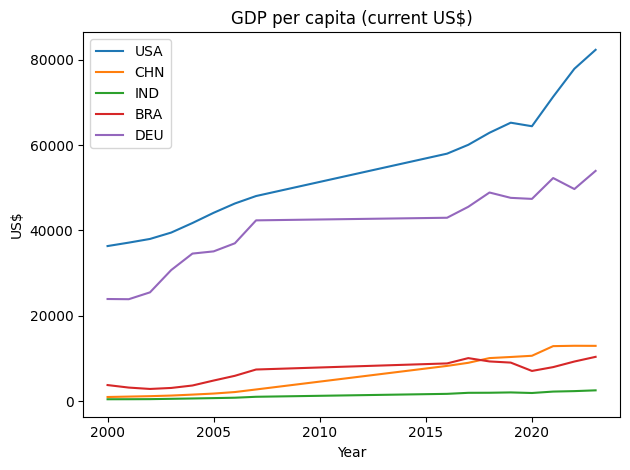

In [41]:
from pathlib import Path
FIG = Path("../figures"); FIG.mkdir(parents=True, exist_ok=True)

# example saving GDP per capita figure
plt.figure()
for c in sample_countries:
    sub = wb[wb["iso3"] == c].sort_values("year")
    plt.plot(sub["year"], sub["gdp_per_capita_usd"], label=c)
plt.title("GDP per capita (current US$)")
plt.xlabel("Year"); plt.ylabel("US$"); plt.legend(); plt.tight_layout()
plt.savefig(FIG / "wbank_gdp_per_capita_lines.png", dpi=150)